In [8]:
import datetime
import itertools
import glob
from concurrent.futures import ProcessPoolExecutor, as_completed

import cartopy.crs as ccrs
import dask.dataframe as dd
import gcsfs
import matplotlib.dates as dates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.auto import tqdm

from pycontrails.utils import temp

# Helper functions, colors, etc

In [2]:
def open_dfs(path):
    """Open and concatenate all dataframes in directory."""
    df_list = [pd.read_parquet(f) for f in tqdm(sorted(glob.glob(f"data/{path}/*.pq")), desc=path)]
    return pd.concat(df_list, axis="index")

In [3]:
def penalty(df, grouping_key):
    """Compute flight distance penalty."""
    return df.groupby(grouping_key)[["adsb_dist_in_forecast_pcr", "adsb_dist"]].apply(
        lambda x: x["adsb_dist_in_forecast_pcr"].sum() / x["adsb_dist"].sum()
    )

In [4]:
def hit_rate(df, grouping_key):
    """Compute hit rate."""
    return df.groupby(grouping_key)[["observed_pcr_area_in_forecast_pcr", "observed_pcr_area"]].apply(
        lambda x: x["observed_pcr_area_in_forecast_pcr"].sum() / x["observed_pcr_area"].sum()
    )

In [5]:
def hit_rate_flight_distance(df, grouping_key):
    """Compute hit rate."""
    return df.groupby(grouping_key)[["flight_distance_in_observed_and_forecast_pcr", "flight_distance_in_observed_pcr"]].apply(
        lambda x: x["flight_distance_in_observed_and_forecast_pcr"].sum() / x["flight_distance_in_observed_pcr"].sum()
    )

In [6]:
exo_black = "#161a26"
tropo_blue = "#1093ff"
solar_orange = "#f26400"
gray50 = "#939598"

In [9]:
fs = gcsfs.GCSFileSystem()
with fs.open("gs://contrails-301217-contrail-bench/tmp/2025Q1/iagos/pcr_flight_m_count.txt") as f:
    pcr_flight_m = float(f.read())
with fs.open("gs://contrails-301217-contrail-bench/tmp/2025Q1/iagos/total_flight_m_count.txt") as f:
    total_flight_m = float(f.read())
iagos_pcr_rate = pcr_flight_m / total_flight_m

# Global

## Contrails.org

In [1]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-adsb data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-gruan data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-contrailwatch data/

In [10]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")
df_contrailwatch = open_dfs("contrails-org-contrailwatch")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch:   0%|          | 0/8784 [00:00<?, ?it/s]

In [11]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "horizontal_buffer"),
})

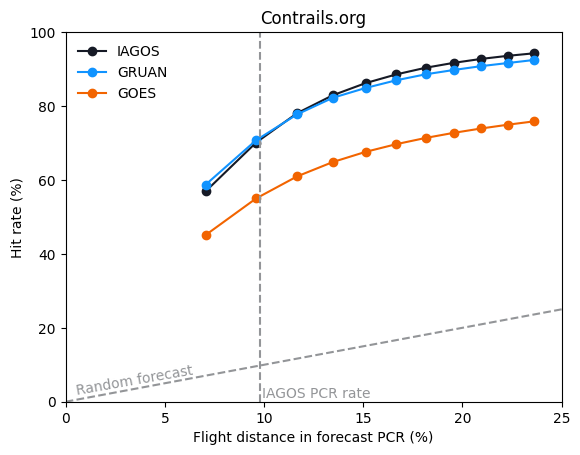

In [12]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org")

plt.savefig("figures/contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/contrails-org.png", dpi=300, bbox_inches="tight");

# Global (flight-distance-weighted hit rate)

## Contrails.org

In [37]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos-flight-distance data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-gruan-flight-distance data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-contrailwatch-flight-distance data/

In [38]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos-flight-distance")
df_gruan = open_dfs("contrails-org-gruan-flight-distance")
df_contrailwatch = open_dfs("contrails-org-contrailwatch-flight-distance")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos-flight-distance:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan-flight-distance:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch-flight-distance:   0%|          | 0/8784 [00:00<?, ?it/s]

In [41]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate_flight_distance(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate_flight_distance(df_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate_flight_distance(df_contrailwatch, "horizontal_buffer"),
})

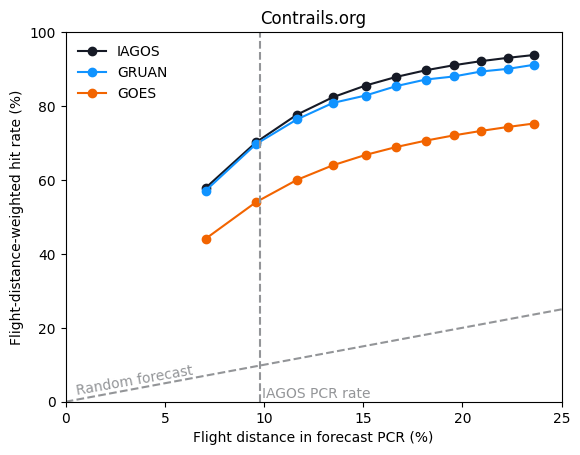

In [42]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Flight-distance-weighted hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org")

plt.savefig("figures/contrails-org-flight-distance.pdf", bbox_inches="tight")
plt.savefig("figures/contrails-org-flight-distance.png", dpi=300, bbox_inches="tight");

# ContrailWatch region

## Contrails.org

In [43]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-adsb-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-gruan-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-contrailwatch-contrailwatch-region data/

In [71]:
df_adsb = open_dfs("contrails-org-adsb-contrailwatch-region")
df_iagos = open_dfs("contrails-org-iagos-contrailwatch-region")
df_gruan = open_dfs("contrails-org-gruan-contrailwatch-region")
df_contrailwatch = open_dfs("contrails-org-contrailwatch-contrailwatch-region")

contrails-org-adsb-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

In [72]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "horizontal_buffer"),
})

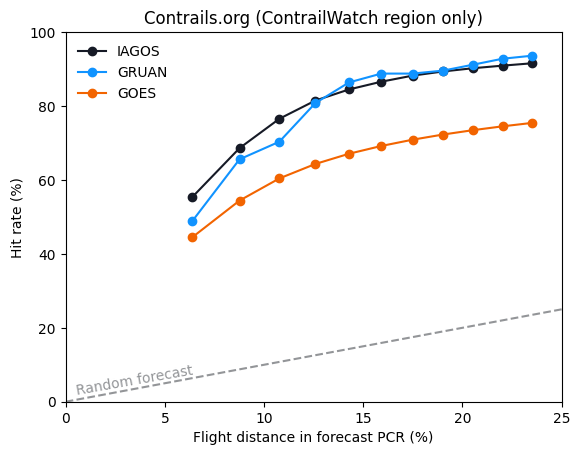

In [73]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (ContrailWatch region only)")

plt.savefig("figures/contrails-org-contrailwatch-region.pdf", bbox_inches="tight")
plt.savefig("figures/contrails-org-contrailwatch-region.png", dpi=300, bbox_inches="tight");

# Global (Sep-Dec only)

## Contrails.org

In [74]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")
df_contrailwatch = open_dfs("contrails-org-contrailwatch")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch:   0%|          | 0/8784 [00:00<?, ?it/s]

In [75]:
df_adsb = df_adsb[df_adsb["time"] >= "2024-09-01 00:00"]
df_iagos = df_iagos[df_iagos["time"] >= "2024-09-01 00:00"]
df_gruan = df_gruan[df_gruan["time"] >= "2024-09-01 00:00"]
df_contrailwatch = df_contrailwatch[df_contrailwatch["time"] >= "2024-09-01 00:00"]

In [76]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "horizontal_buffer"),
})

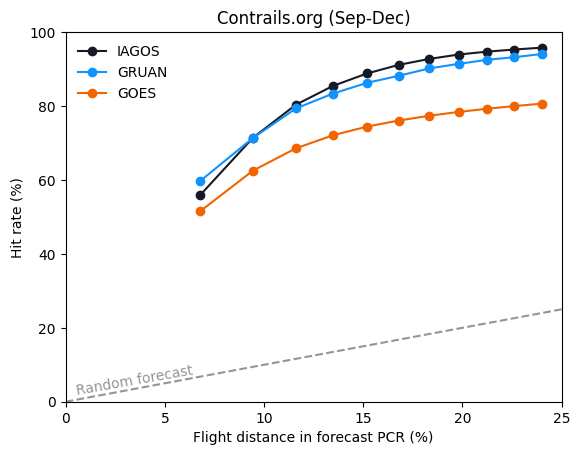

In [77]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Sep-Dec)")

plt.savefig("figures/contrails-org-sep-dec.pdf", bbox_inches="tight")
plt.savefig("figures/contrails-org-sep-dec.png", dpi=300, bbox_inches="tight");

## Google

In [94]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-adsb data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-iagos data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-gruan data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-contrailwatch data/

In [95]:
df_adsb = open_dfs("google-adsb")
df_iagos = open_dfs("google-iagos")
df_gruan = open_dfs("google-gruan")
df_contrailwatch = open_dfs("google-contrailwatch")

google-adsb:   0%|          | 0/2928 [00:00<?, ?it/s]

google-iagos:   0%|          | 0/2928 [00:00<?, ?it/s]

google-gruan:   0%|          | 0/2928 [00:00<?, ?it/s]

google-contrailwatch:   0%|          | 0/2928 [00:00<?, ?it/s]

In [96]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "probability_threshold"),
    "iagos_hit_rate": hit_rate(df_iagos, "probability_threshold"),
    "gruan_hit_rate": hit_rate(df_gruan, "probability_threshold"),
    "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "probability_threshold"),
})

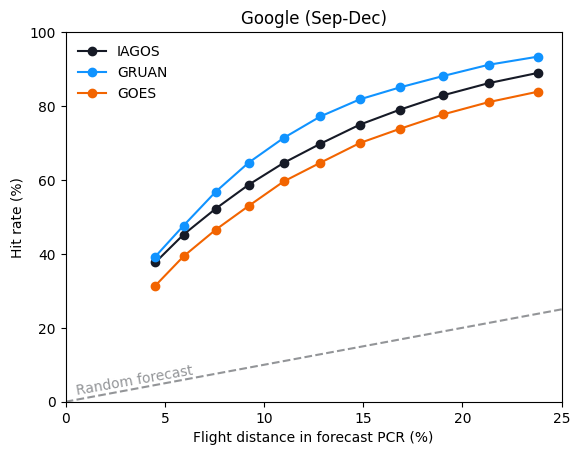

In [97]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google (Sep-Dec)")

plt.savefig("figures/google-sep-dec.pdf", bbox_inches="tight")
plt.savefig("figures/google-sep-dec.png", dpi=300, bbox_inches="tight");

# Global (flight-distance-weighted hit rate, Sep-Dec only)

## Contrails.org

In [47]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos-flight-distance")
df_gruan = open_dfs("contrails-org-gruan-flight-distance")
df_contrailwatch = open_dfs("contrails-org-contrailwatch-flight-distance")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos-flight-distance:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan-flight-distance:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch-flight-distance:   0%|          | 0/8784 [00:00<?, ?it/s]

In [48]:
df_adsb = df_adsb[df_adsb["time"] >= "2024-09-01 00:00"]
df_iagos = df_iagos[df_iagos["time"] >= "2024-09-01 00:00"]
df_gruan = df_gruan[df_gruan["time"] >= "2024-09-01 00:00"]
df_contrailwatch = df_contrailwatch[df_contrailwatch["time"] >= "2024-09-01 00:00"]

In [49]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate_flight_distance(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate_flight_distance(df_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate_flight_distance(df_contrailwatch, "horizontal_buffer"),
})

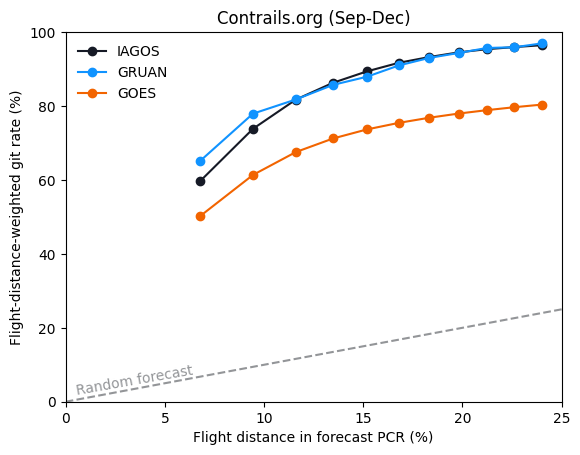

In [50]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Flight-distance-weighted git rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Sep-Dec)")

plt.savefig("figures/contrails-org-sep-dec-flight-distance.pdf", bbox_inches="tight")
plt.savefig("figures/contrails-org-sep-dec-flight-distance.png", dpi=300, bbox_inches="tight");

## Google

In [98]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-iagos-flight-distance data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-gruan-flight-distance data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-contrailwatch-flight-distance data/

In [99]:
df_adsb = open_dfs("google-adsb")
df_iagos = open_dfs("google-iagos-flight-distance")
df_gruan = open_dfs("google-gruan-flight-distance")
df_contrailwatch = open_dfs("google-contrailwatch-flight-distance")

google-adsb:   0%|          | 0/2928 [00:00<?, ?it/s]

google-iagos-flight-distance:   0%|          | 0/2928 [00:00<?, ?it/s]

google-gruan-flight-distance:   0%|          | 0/2928 [00:00<?, ?it/s]

google-contrailwatch-flight-distance:   0%|          | 0/2928 [00:00<?, ?it/s]

In [102]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "probability_threshold"),
    "iagos_hit_rate": hit_rate_flight_distance(df_iagos, "probability_threshold"),
    "gruan_hit_rate": hit_rate_flight_distance(df_gruan, "probability_threshold"),
    "contrailwatch_hit_rate": hit_rate_flight_distance(df_contrailwatch, "probability_threshold"),
})

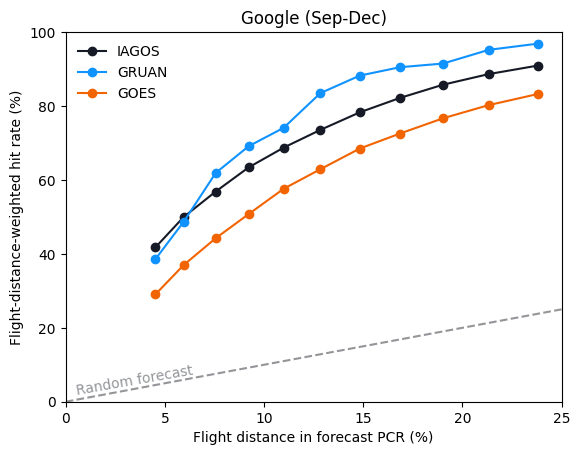

In [103]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Flight-distance-weighted hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google (Sep-Dec)")

plt.savefig("figures/google-sep-dec-flight-distance.pdf", bbox_inches="tight")
plt.savefig("figures/google-sep-dec-flight-distance.png", dpi=300, bbox_inches="tight");

# ContrailWatch region (Sep-Dec only)

## Contrails.org

In [55]:
df_adsb = open_dfs("contrails-org-adsb-contrailwatch-region")
df_iagos = open_dfs("contrails-org-iagos-contrailwatch-region")
df_gruan = open_dfs("contrails-org-gruan-contrailwatch-region")
df_contrailwatch = open_dfs("contrails-org-contrailwatch-contrailwatch-region")

contrails-org-adsb-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

In [56]:
df_adsb = df_adsb[df_adsb["time"] >= "2024-09-01 00:00"]
df_iagos = df_iagos[df_iagos["time"] >= "2024-09-01 00:00"]
df_gruan = df_gruan[df_gruan["time"] >= "2024-09-01 00:00"]
df_contrailwatch = df_contrailwatch[df_contrailwatch["time"] >= "2024-09-01 00:00"]

In [57]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "horizontal_buffer"),
})

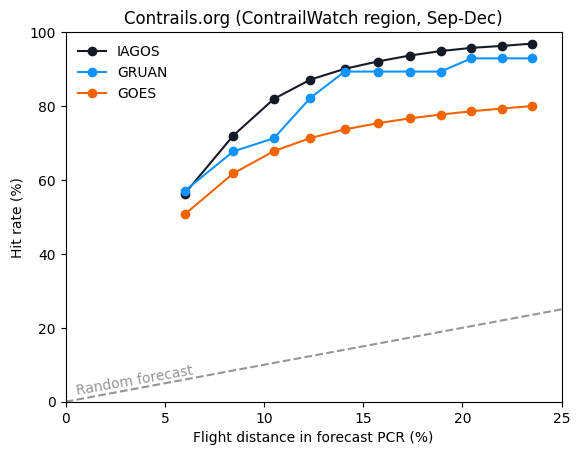

In [59]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (ContrailWatch region, Sep-Dec)")

plt.savefig("figures/contrails-org-sep-dec-contrailwatch-region.pdf", bbox_inches="tight")
plt.savefig("figures/contrails-org-sep-dec-contrailwatch-region.png", dpi=300, bbox_inches="tight");

## Google

In [78]:
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-adsb-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-iagos-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-gruan-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/google-contrailwatch-contrailwatch-region data/

In [79]:
df_adsb = open_dfs("google-adsb-contrailwatch-region")
df_iagos = open_dfs("google-iagos-contrailwatch-region")
df_gruan = open_dfs("google-gruan-contrailwatch-region")
df_contrailwatch = open_dfs("google-contrailwatch-contrailwatch-region")

google-adsb-contrailwatch-region:   0%|          | 0/2928 [00:00<?, ?it/s]

google-iagos-contrailwatch-region:   0%|          | 0/2928 [00:00<?, ?it/s]

google-gruan-contrailwatch-region:   0%|          | 0/2928 [00:00<?, ?it/s]

google-contrailwatch-contrailwatch-region:   0%|          | 0/2928 [00:00<?, ?it/s]

In [82]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "probability_threshold"),
    "iagos_hit_rate": hit_rate(df_iagos, "probability_threshold"),
    "gruan_hit_rate": hit_rate(df_gruan, "probability_threshold"),
    "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "probability_threshold"),
})

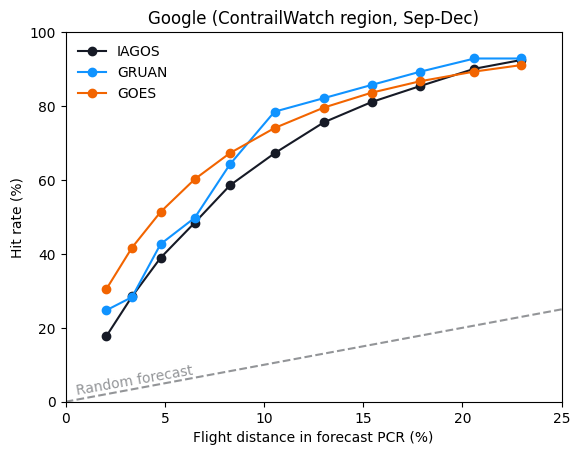

In [83]:
plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "-o", color=exo_black, label="IAGOS")
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "-o", color=solar_orange, label="GOES")
plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 25])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
# plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
# plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Google (ContrailWatch region, Sep-Dec)")

plt.savefig("figures/google-sep-dec-contrailwatch-region.pdf", bbox_inches="tight")
plt.savefig("figures/google-sep-dec-contrailwatch-region.png", dpi=300, bbox_inches="tight");

# Relative number of observations

In [60]:
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")
df_contrailwatch = open_dfs("contrails-org-contrailwatch")
df_iagos_fd = open_dfs("contrails-org-iagos-flight-distance")
df_gruan_fd = open_dfs("contrails-org-gruan-flight-distance")
df_contrailwatch_fd = open_dfs("contrails-org-contrailwatch-flight-distance")

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos-flight-distance:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan-flight-distance:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch-flight-distance:   0%|          | 0/8784 [00:00<?, ?it/s]

In [61]:
iagos = df_iagos[df_iagos["horizontal_buffer"] == 0]
area_iagos = iagos.groupby(iagos["time"].dt.date)["observed_pcr_area"].mean()

gruan = df_gruan[df_gruan["horizontal_buffer"] == 0]
area_gruan = gruan.groupby(gruan["time"].dt.date)["observed_pcr_area"].mean()

contrailwatch = df_contrailwatch[df_contrailwatch["horizontal_buffer"] == 0]
area_contrailwatch = contrailwatch.groupby(contrailwatch["time"].dt.date)["observed_pcr_area"].mean()

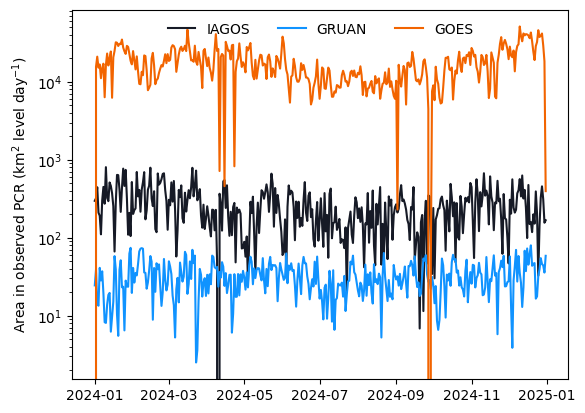

In [69]:
plt.plot(area_iagos.index, area_iagos / 1e6, "-", color=exo_black, label="IAGOS")
plt.plot(area_gruan.index, area_gruan / 1e6, "-", color=tropo_blue, label="GRUAN")
plt.plot(area_contrailwatch.index, area_contrailwatch / 1e6, "-", color=solar_orange, label="GOES")
plt.ylabel("Area in observed PCR (km$^2$ level day$^{-1}$)")
plt.gca().set_yscale("log")
plt.legend(loc="upper center", frameon=False, ncol=3)

plt.savefig("figures/observed-pcr-area.pdf", bbox_inches="tight")
plt.savefig("figures/observed-pcr-area.png", dpi=300, bbox_inches="tight");

In [66]:
iagos = df_iagos_fd[df_iagos_fd["horizontal_buffer"] == 0]
dist_iagos = iagos.groupby(iagos["time"].dt.date)["flight_distance_in_observed_pcr"].mean()

gruan = df_gruan_fd[df_gruan_fd["horizontal_buffer"] == 0]
dist_gruan = gruan.groupby(gruan["time"].dt.date)["flight_distance_in_observed_pcr"].mean()

contrailwatch = df_contrailwatch_fd[df_contrailwatch_fd["horizontal_buffer"] == 0]
dist_contrailwatch = contrailwatch.groupby(contrailwatch["time"].dt.date)["flight_distance_in_observed_pcr"].mean()

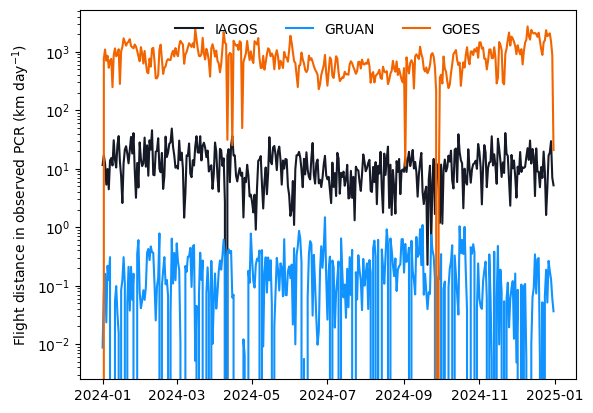

In [70]:
plt.plot(dist_iagos.index, dist_iagos / 1e3, "-", color=exo_black, label="IAGOS")
plt.plot(dist_gruan.index, dist_gruan / 1e3, "-", color=tropo_blue, label="GRUAN")
plt.plot(dist_contrailwatch.index, dist_contrailwatch / 1e3, "-", color=solar_orange, label="GOES")
plt.ylabel("Flight distance in observed PCR (km day$^{-1}$)")
plt.gca().set_yscale("log")
plt.legend(loc="upper center", frameon=False, ncol=3)

plt.savefig("figures/flight-distance-in-observed-pcr.pdf", bbox_inches="tight")
plt.savefig("figures/flight-distance-in-observed-pcr.png", dpi=300, bbox_inches="tight");